In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import kibble_zurek as kz
from itertools import combinations
from collections import Counter
import adprox

In [2]:
taus = np.logspace(-3,3,2000)

In [3]:
from joblib import Parallel, delayed
from numpy import array
from tqdm import tqdm

states = array(
    Parallel(n_jobs=-1)(
        delayed(state)(512, tau, tau) for tau in tqdm(taus)
    )
)


100%|██████████| 2000/2000 [03:17<00:00, 10.12it/s]


In [6]:
ns = [2,3,4,5,6,7,8,9,10,11,12]

#P_mat = array([array([Px(n,s) for s in states]) for n in ns])



def Px_state(s, n):
    return Px(n, s)

P_mat = np.array([
    np.array(
        Parallel(n_jobs=-1)(
            delayed(Px_state)(s, n) for s in states
        )
    )
    for n in tqdm(ns)
])


100%|██████████| 11/11 [02:57<00:00, 16.16s/it]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8139/3445814744.py:5: UserWarning: linewidths is ignored by contourf
  plt.contourf(X, Y, Z, levels=40, linewidths=2)


(2.0, 12.0)

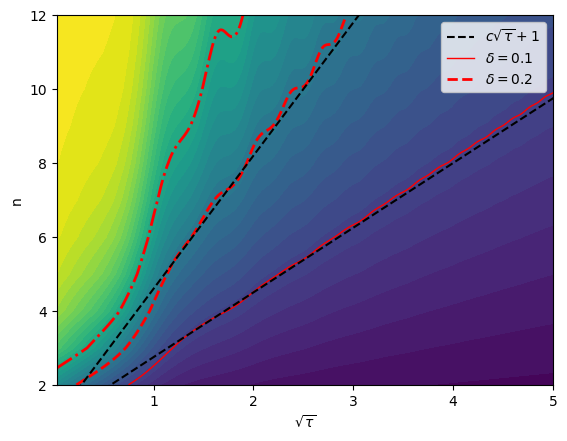

In [101]:
from matplotlib.lines import Line2D

levels_red = [0.1, 0.2,.3]

plt.contourf(X, Y, Z, levels=40, linewidths=2)
plt.contour(X, Y, Z, levels=[levels_red[0]], colors="red", linewidths=1)
plt.contour(X, Y, Z, levels=[levels_red[1]], colors="red", linewidths=2, linestyles="--")
plt.contour(X, Y, Z, levels=[levels_red[2]], colors="red", linewidths=2, linestyles="-.")

line_black, = plt.plot(np.sqrt(taus), 1.75*np.sqrt(taus)+1, "--k",
                       label=r"$c\sqrt{\tau}+1$")
line_black, = plt.plot(np.sqrt(taus), 3.6*np.sqrt(taus)+1, "--k",
                       label=r"$c\sqrt{\tau}+1$")
proxy_red1 = Line2D([0], [0], color="red", lw=1,
                    label=rf"$\delta = {levels_red[0]}$")
proxy_red2 = Line2D([0], [0], color="red", lw=2, linestyle="--",
                    label=rf"$\delta = {levels_red[1]}$")

plt.legend(handles=[line_black, proxy_red1, proxy_red2])

plt.xlabel(r"$\sqrt{\tau}$")
plt.ylabel("n")
plt.xlim(X[0], 5)
plt.ylim(Y[0], Y[-1])


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8139/3803274914.py:29: RuntimeWarning: Mean of empty slice.
  f_vals.append(f_delta_all.mean())


[]

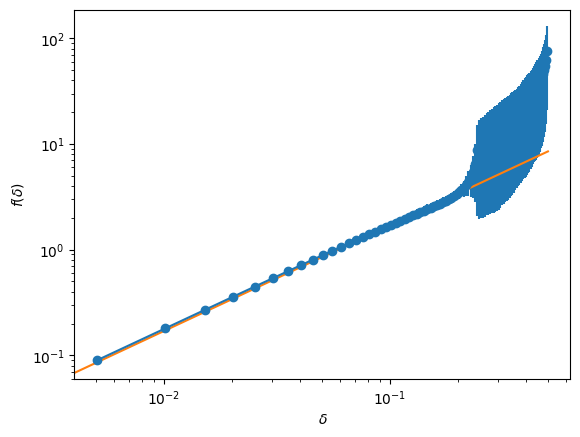

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# inputs assumed defined:
# X = sqrt(taus)          shape (Nx,)
# Y = ns                  shape (Ny,)
# Z = 0.5 - P_mat.real    shape (Ny, Nx)

c = 1.0
deltas = np.linspace(0,.5,100)

f_vals = []
f_errs = []

for delta in deltas:
    cs = plt.contour(X, Y, Z, levels=[delta])
    segs = cs.allsegs[0]

    f_delta_all = []

    for seg in segs:              # handle multiple connected components
        sqrt_tau = seg[:, 0]
        n_line   = seg[:, 1]
        f_num    = (n_line - c) / sqrt_tau
        f_delta_all.append(f_num)

    f_delta_all = np.concatenate(f_delta_all)

    f_vals.append(f_delta_all.mean())
    f_errs.append(f_delta_all.std())

    plt.clf()  # prevent contour accumulation

f_vals = np.array(f_vals)
f_errs = np.array(f_errs)

# visualize f(delta)
plt.errorbar(deltas, f_vals, yerr=f_errs, fmt="o-")
plot(deltas,17*deltas)
plt.xlabel(r"$\delta$")
plt.ylabel(r"$f(\delta)$")
#plt.show()
loglog()


In [419]:
P0 = array([array([adprox.P_n(n,tau) for tau in tqdm(taus)]) for n in ns])

100%|██████████| 2000/2000 [00:00<00:00, 150988.30it/s]


100%|██████████| 2000/2000 [01:21<00:00, 24.65it/s]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2951/473002270.py:1: UserWarning: The following kwargs were not used by contour: 'aspect'
  plt.contourf(taus,ns,1/2-P0.real, aspect="auto", origin="lower", extent=[taus[0],taus[-1], ns[0], ns[-1]],levels=20);


(1.0, 10.0)

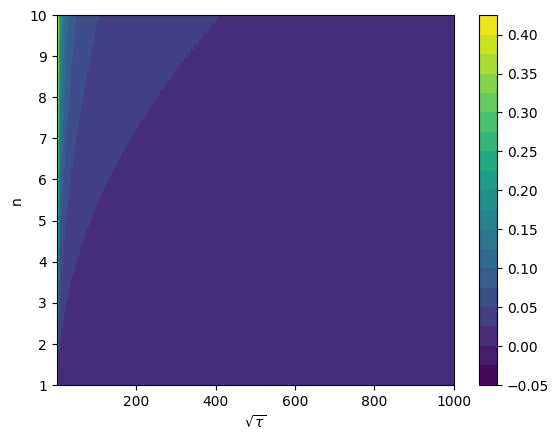

In [420]:
plt.contourf(taus,ns,1/2-P0.real, aspect="auto", origin="lower", extent=[taus[0],taus[-1], ns[0], ns[-1]],levels=20); 
plt.colorbar(); 
plt.xlabel(r"$\sqrt{\tau}$")
plt.ylabel("n")
#plot(sqrt(taus),sqrt(taus)/2)
#xscale("log")
ylim(ns[0],ns[-1])
#xlim(sqrt(taus[0]),sqrt(taus[-1]))
##yscale("log")
#loglog()

In [316]:
print(1/18)

print(sqrt(2*pi)*2)

0.05555555555555555
5.0132565492620005


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2951/3590406317.py:3: UserWarning: linewidths is ignored by contourf
  plt.contourf(X, Y, Z, linewidths=2,levels=20)


(0.03162277660168379, 4.0)

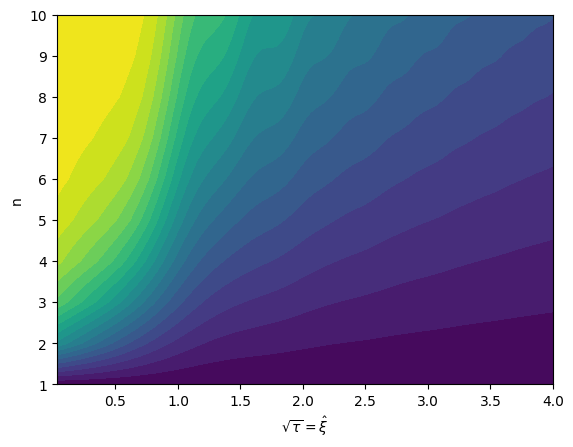

In [431]:
levels1 = np.linspace(0,.4,10)
plt.figure()
plt.contourf(X, Y, Z, linewidths=2,levels=20)

for level in levels1[1:]:
    #cs = plt.contour(X, Y, Z, levels=[level]);

    #cs.allsegs[level_index] is a list of segments
    segs = cs.allsegs[0]          # list of (N_i, 2) arrays
    seg  = segs[0]                # choose first connected component

    sqrt_tau_line = seg[:, 0]
    n_line        = seg[:, 1]

    tau_line = sqrt_tau_line
    #plt.plot((tau_line), n_line, "--k",lw=2,label=f"{level}",)
    #plt.plot(tau_line,18.*level*tau_line+1,"--k")


    plt.xlabel(r"$\sqrt{\tau}= \hat \xi$")
    plt.ylabel("n")
    #plt.xscale("log")
    #yscale("log")
   # xlim(1,100)
    plt.ylim(ns[0], ns[-1])
#legend()
xlim(X[0],4)


In [432]:
exp(1)

np.float64(2.718281828459045)

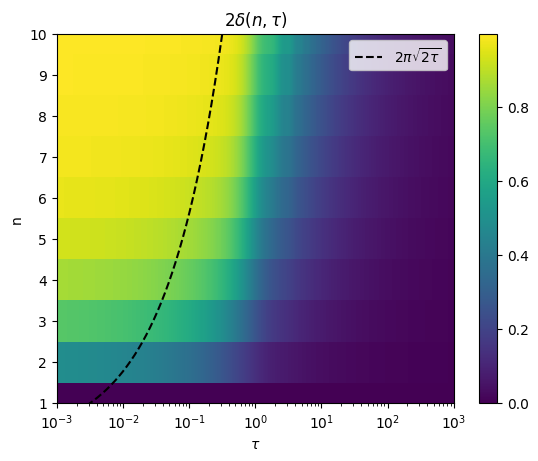

In [409]:
plt.figure()

Xg, Yg = np.meshgrid(X**2, Y)

pcm = plt.pcolormesh(
    Xg, Yg, 2*Z,
    shading="nearest"   # <-- critical: no interpolation
)
plot(X**2,4*sqrt(2)*pi*X,"--k",label=r"$2 \pi \sqrt{2 \tau}$")
plt.colorbar(pcm)
plt.xlabel(r"$\tau$")
plt.ylabel("n")
plt.ylim(ns[0], ns[-1])
plt.xscale("log")
title(r"$2\delta(n,\tau)$")
legend()

np.float64(20.297778478021115)

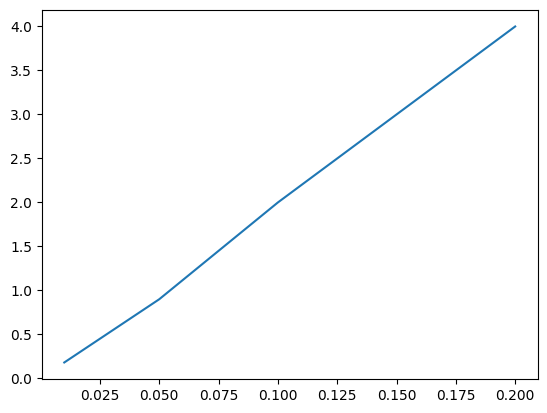

In [308]:
insane = [0.01,0.05,.1,.15,.2]
d = [1/5.5,.9,2,3,4]

plot(insane,d)

import numpy as np

x = np.array([0.01, 0.05, 0.1, 0.15, 0.2])
y = np.array([1/5.5, 0.9, 2, 3, 4])

m, b = np.polyfit(x, y, 1)
m


In [171]:
Z = 0.5 - P_mat.real
X = np.sqrt(taus)
Y = ns


ns/X

ValueError: operands could not be broadcast together with shapes (11,) (2000,) 

[]

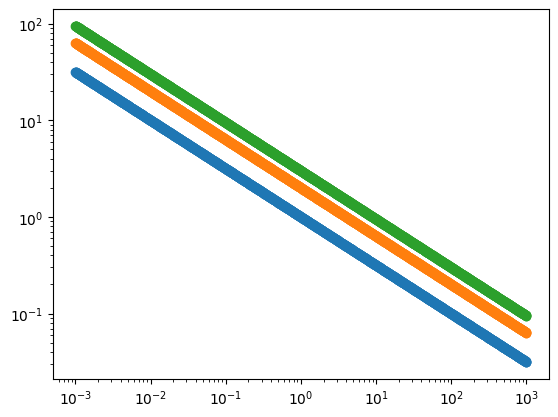

In [183]:
scatter(taus,1/X)
scatter(taus,2/X)
scatter(taus,3/X)
loglog()

In [188]:
for n in ns:
    print(n)
    print(100/n)

1
100.0
2
50.0
3
33.333333333333336
4
25.0
5
20.0
6
16.666666666666668
7
14.285714285714286
8
12.5
9
11.11111111111111
10
10.0
11
9.090909090909092


In [265]:
cs = [100,50,25,12,4,2,1.5,1,.5]
for c in cs:
    #c = .2                      # desired constant n/sqrt(tau)
    ns = np.arange(1, 11)
    taus = (ns / c)**2              # enforces n/sqrt(tau)=c
    print(taus)
    dat=[]
    for n,tau in zip(ns,taus):
        print(n,tau)
        s = kz.state(512,tau,tau)
        dat.append(1/2-Px(n,s))

    plot(ns,dat,label=c)
legend()


[0.0001 0.0004 0.0009 0.0016 0.0025 0.0036 0.0049 0.0064 0.0081 0.01  ]
1 0.0001
2 0.0004
3 0.0009
4 0.0016
5 0.0025000000000000005


KeyboardInterrupt: 

  0%|          | 0/12 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
100%|██████████| 12/12 [00:19<00:00,  1.65s/it]


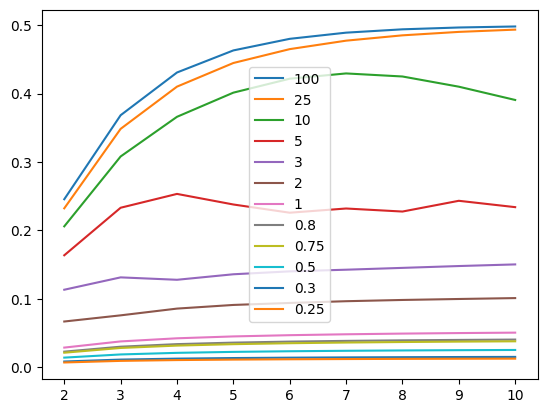

In [248]:
from joblib import Parallel, delayed

def compute_point(n, tau):
    s = kz.state(512, tau, tau)
    return 0.5 - Px(n, s)

cs = [100,25,10,5,3,2,1,.8,.75,.5,.3,.25]
ns = np.arange(2, 11)

for c in tqdm(cs):
    taus = (ns / c)**2

    dat = Parallel(n_jobs=-1)(
        delayed(compute_point)(n, tau) for n, tau in zip(ns, taus)
    )

    plot(ns, dat, label=c)
#yscale("log")
legend()


In [345]:
defect = 0.1*18
xi = 8
tau = xi*xi

print(defect*xi+1)

s0 = state(512,tau,tau)
1/2-Px(int(defect*xi+1),s0)

15.4


np.complex128(0.0981221702419724+0j)

ModuleNotFoundError: No module named 'plotly'